# MCMC for the identification of uncertain paramters in MEMS

In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt


## Definition of spring stiffness as a function of OE

In [2]:
def generate_K(OE): # OE: double-sided overetch (um) 

    L = 200e-6              # [m] length of the beam
    E = 160e9               # [Pa] Young's Module of long beam
    b = (2.8 - OE)*1e-6     # [m] width of the beam
    h = 30e-6               # [m] height of the beam
    I = h*b**3/12           # [m^4] second moment of area
    K = 1/6 * 12*E*I/L**3   # [N/m] stiffness of the beam

    return K
    

## Definition of the dynamic model  

$$ m\ddot x + c\dot x + k(u)x = \frac{1}{2}\frac{\epsilon A}{(g-x)^2}V^2 $$

$$
\frac{d}{dt}
\begin{bmatrix}
x\\
\dot{x}
\end{bmatrix}
=
\begin{bmatrix}
0 & 1\\
-\dfrac{k}{m} & -\dfrac{c}{m}
\end{bmatrix}
\begin{bmatrix}
x\\
\dot{x}
\end{bmatrix}
+
\begin{bmatrix}
0\\
\dfrac{\varepsilon A V^2}{2m(u-x)^2}
\end{bmatrix}
$$

$$V(t)=1.2\times\sin(1200\times2\pi\times t)$$

In [3]:
def Analytical_Model(OE):  # OE: double-sided overetch (um) 

    # parameters
    K = generate_K(OE)      # stiffness [N/m]
    M = 5.6e-09             # [kg]
    Q = 0.7                 # Q factor
    eigen = np.sqrt(K/M)    # eigen frequency
    C_damping = eigen/Q*M   # damping coefficient
    eps = 8.854e-12         # [F/m] vacuum permittivity
    A = 30e-6*200e-6 * 10   # [m^2] area of the electrode and 10 plates
    g = 2e-6                # [m] gap of capacitor

    # Initial condition
    x0 = [0.0,              # initial displacement [m]
          0.0]              # initial velocity [m/s]

    # time setting
    h = 5e-6                # time step [s]
    t_0 = 0                 # initial time [s]
    step = 600              # number of steps
    t_span = [t_0, step*h]  # time span [s]
    t_eval=np.arange(t_0, step*h, h)

    # RK4 solution
    def ode(t, state, *args):
        x = state[0]
        dx = state[1]
        V = 1.2 * np.sin(1200*np.pi*t) * (t<2/1200)  # voltage [V]
        ddx = -K/M*x - C_damping/M*dx + 1/2*eps*A/M/(g-x)**2*V**2
        return [dx, ddx]

    sol = solve_ivp(ode, t_span, x0, args=(K, M, C_damping, eps, A, g), t_eval=t_eval)
    disp = sol.y[0]
    
    return disp
    

## Generates noisy measurements

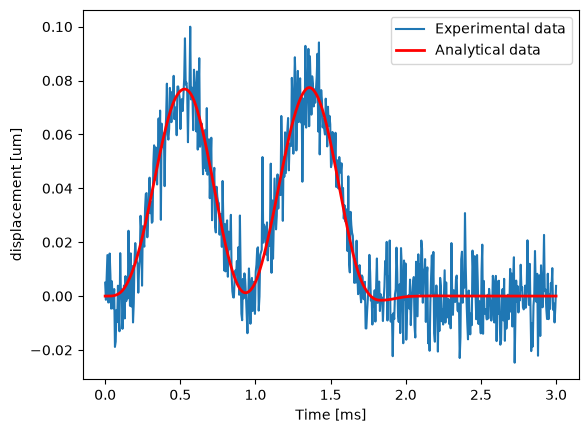

In [4]:
x_true = np.array(0.45)      # real value of OE
y_true = Analytical_Model(x_true)  # computes the time history of displacements for real value of OE
nstep = len(y_true)

# corrupts data by adding Gaussian noise to the true data
sigma_noise = 1e-8 
np.random.seed(42)
y_observed = y_true + sigma_noise * np.random.randn(nstep)

# plot readout signal
t = np.linspace(0, 5e-6*nstep, nstep)
plt.figure()
plt.plot(t*1000, y_observed*1e6,label='Experimental data')
plt.plot(t*1000, y_true*1e6,label='Analytical data', color="red", linewidth="2")
plt.legend()
plt.xlabel('Time [ms]')
plt.ylabel('displacement [um]')
plt.show()


# MCMC Bayesian Inference

In [5]:
nchains = 2 # number of chains that will be computed

MCMC_SETTINGS = {
    'N': 1000,      # number of production samples
    'Nb': 500,      # number of burn-in samples
    'Nt': 1         # thinning factor: 1 = no thinning
}

# Gaussian random-walk proposal standard deviation
proposal_std = 0.01


## Prior definition

In [6]:
prior_mean = 0.35
prior_std = 0.07

# Logarithm of the Gaussian prior, apart from additive constants.
def log_prior(x):

    return -0.5 * ((x - prior_mean) / prior_std)**2


## Likelihood definition

In [7]:
def log_likelihood(x):
    """
    Logarithm of the likelihood, apart from additive constants.
    y_observed = Analytical_Model(x) + noise ~ N(0, sigma_noise^2 I)
    """

    residual = y_observed - Analytical_Model(x)

    return -0.5 * np.sum(residual**2) / sigma_noise**2


## Posterior definition

In [8]:
def log_posterior(x):

    return log_prior(x) + log_likelihood(x)


## Metropolis algorithm 

In [9]:
def metropolis(x0, N, Nb, proposal_std):

    # total number of MCMC iterations
    N_total = Nb + N

    # storage
    chain = np.zeros(N_total + 1)
    chain[0] = x0

    # evaluate posterior at initial point
    log_post_current = log_posterior(x0)

    accepted = 0

    for k in range(N_total):

        x_current = chain[k]

        # Gaussian random-walk proposal
        x_proposed = x_current + proposal_std * np.random.randn()

        # Posterior at proposed point
        log_post_proposed = log_posterior(x_proposed)

        # Metropolis acceptance probability
        log_alpha = log_post_proposed - log_post_current

        # accept if log(U) < log(alpha) with U ~ Uniform(0,1) 
        if np.log(np.random.rand()) < min(0.0, log_alpha):

            chain[k+1] = x_proposed
            log_post_current = log_post_proposed
            accepted += 1

        else:

            chain[k+1] = x_current

    acceptance_rate = accepted / N_total
    
    chain = chain[1:] # remove initial value
    chain = chain[Nb:] # remove burn-in
    chain = chain[::MCMC_SETTINGS['Nt']]  # thinning 

    return chain, acceptance_rate
    

In [10]:
initial_guesses = np.linspace(0.20, 0.50, nchains)

print(f"True value: {x_true}")
print(f"Starting points: {initial_guesses}")

# ============================================================
# RUN CHAINS
# ============================================================

samples_mh = []

for i, x0 in enumerate(initial_guesses):

    samples, acceptance_rate = metropolis(
        x0=x0,
        N=MCMC_SETTINGS['N'],
        Nb=MCMC_SETTINGS['Nb'],
        proposal_std=proposal_std
    )

    samples_mh.append(samples)

    print(
        f"Chain {i+1}: "
        f"acceptance rate = {acceptance_rate:.3f}, "
        f"mean = {np.mean(samples):.5f}, "
        f"std = {np.std(samples):.5f}"
    )

True value: 0.45
Starting points: [0.2 0.5]
Chain 1: acceptance rate = 0.664, mean = 0.45069, std = 0.00911
Chain 2: acceptance rate = 0.694, mean = 0.45069, std = 0.00900


## Final operations

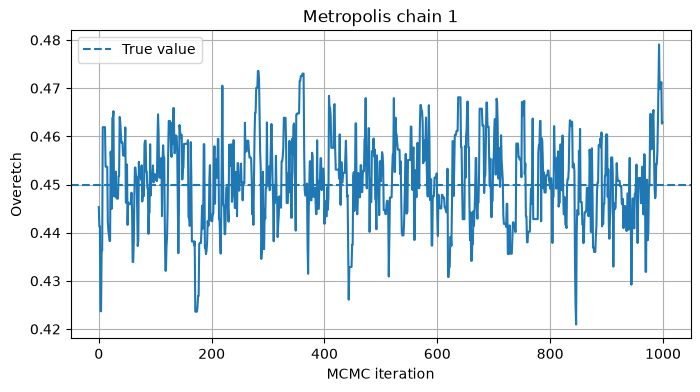

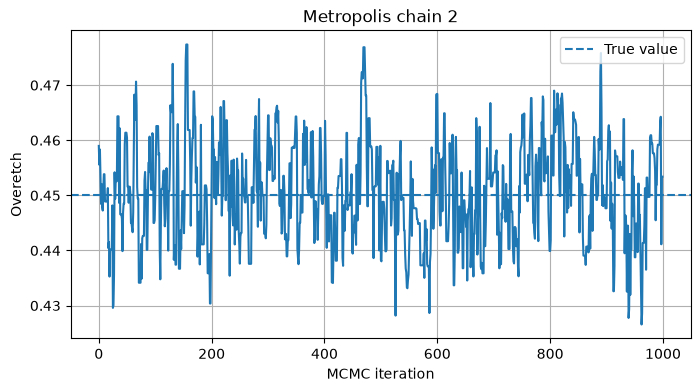

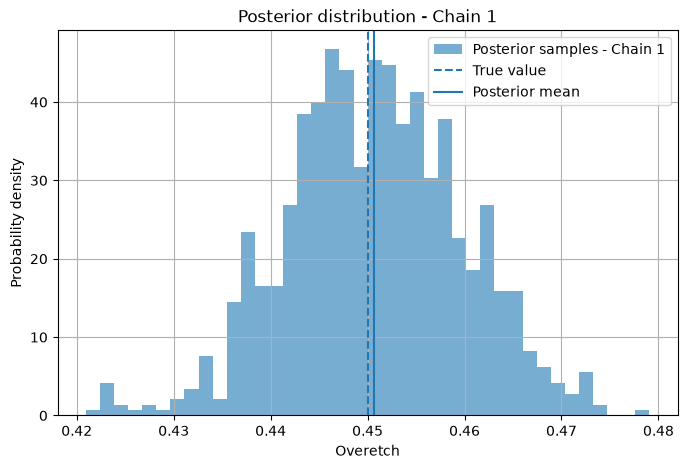

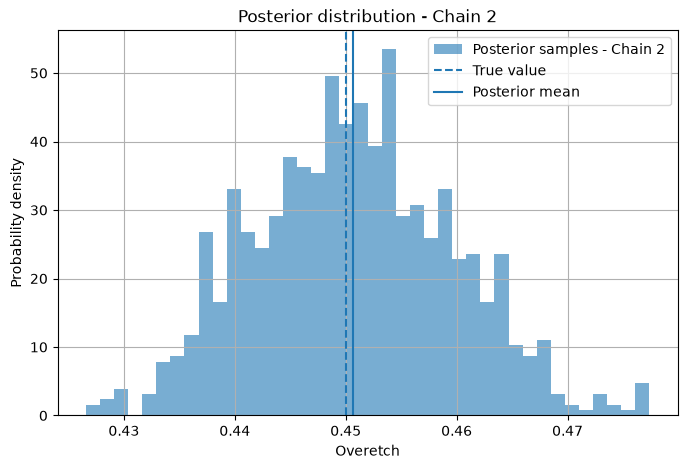

In [11]:

# Plots chains

for i in range(nchains):

    plt.figure(figsize=(8, 4))
    plt.plot(samples_mh[i])

    plt.axhline(
        x_true,
        linestyle='--',
        label='True value'
    )

    plt.xlabel('MCMC iteration')
    plt.ylabel('Overetch')
    plt.title(f'Metropolis chain {i+1}')
    plt.legend()
    plt.grid()

    plt.show()    
   

# Plots posterior distributions

for i in range(nchains):

    posterior_mean = np.mean(samples_mh[i])
    posterior_variance = np.var(samples_mh[i], ddof=1)

    plt.figure(figsize=(8, 5))

    plt.hist(
        samples_mh[i],
        bins=40,
        density=True,
        alpha=0.6,
        label=f'Posterior samples - Chain {i+1}'
    )

    plt.axvline(
        x_true,
        linestyle='--',
        label='True value'
    )

    plt.axvline(
        posterior_mean,
        linestyle='-',
        label='Posterior mean'
    )

    plt.xlabel('Overetch')
    plt.ylabel('Probability density')
    plt.title(f'Posterior distribution - Chain {i+1}')
    plt.legend()
    plt.grid()

    plt.show()